In [291]:
import os, time
import numpy as np
import matplotlib.pyplot as plt
from redpitaya_control.redpitaya_dev import redpitaya_dev
from redpitaya_control.event_logger import EventLogger, unpack, load_run, fit_clock, counter_to_unix
from redpitaya_control import compute_coeff


runfile = 'run3'

MAX_Q15 = 32767 / 32768
C1 = 99.90741625
C2 = 1225.60912165
C3 = 1024.0
C4 = 14.4



MAX_Q15 = 32767 / 32768

In [292]:


RP_HOST = os.environ.get("RP_HOST", "171.64.56.120")
dev = redpitaya_dev(RP_HOST, "config/mca_timestamp_1ch_working.json")
dev.base.load_bitfile()

# Signal chain
dev.set_all_registers(
    "iir1",
    compute_coeff.highpass_1st(1e4, Ts=16e-9),
    reset=True,
)

for idx in range(9):
    dev.set_register("fir9", f"h{idx}", 0.109375)

# Do not use raw=True for normalized Q15 values.
dev.set_register("peak_detector", "trig_level", 0.008)
dev.set_register("peak_detector", "invert_input", 0)
dev.set_register("peak_detector", "n_integration", 300)
dev.set_register("peak_detector", "dead_time", 300)
# Histogram
dev.set_register("histogram", "offset", -0.007165694774164504)
dev.set_register("histogram", "gain", 0.08361136196556104)
dev.set_register("histogram", "pulse_width", 1024)

dev.set_register("histogram", "clear_bins", 1)
time.sleep(0.01)
dev.set_register("histogram", "clear_bins", 0)
dev.set_register("histogram", "counting_enable", 1,)

# Configure before arming.
log = EventLogger(dev)
log.configure(
    band_low=0.0,
    band_high=MAX_Q15,
    flush_ms=100,
)
print(dev.get_register("peak_detector", "dead_time", raw=True))

n = log.run(duration=20, output_dir=runfile)



300
Logged 52172 events, dropped=0


In [293]:

# print("drained events:", n)
# print("FPGA events:",
#       dev.get_register("event_logger", "events_lo"))
# print("dropped:", log.dropped())
raw = load_run(f"{runfile}/events_*.bin")
ts_us, energy, chb = unpack(raw)

print(f"{len(ts_us)} events, span {(ts_us[-1]-ts_us[0])/1e6:.1f} s" if len(ts_us) > 1 else "no events")
a, b, ppm = fit_clock(f"{runfile}/tiepoints.csv")
print(f"Crystal drift: {ppm:+.1f} ppm")
t_unix = counter_to_unix(ts_us, a, b)

26305 events, span 19.1 s
Crystal drift: -192.1 ppm


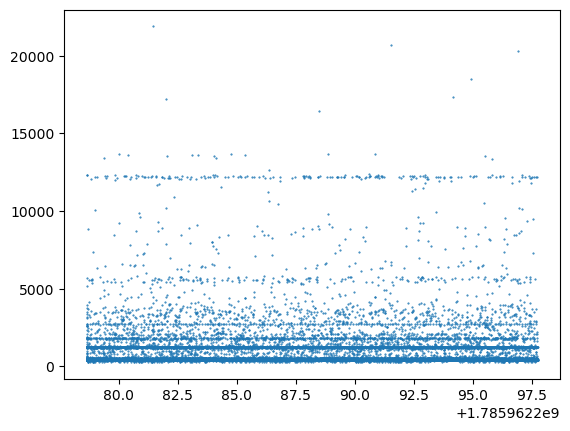

In [294]:
plt.plot(t_unix, energy, '.', markersize=1)

(-1.0, 2.0)

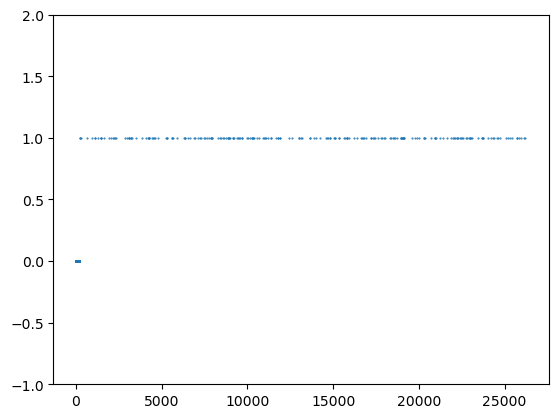

In [301]:
plt.plot(ts_us[1:]-ts_us[:-1], '.', markersize=1)
plt.ylim(-1, 2)

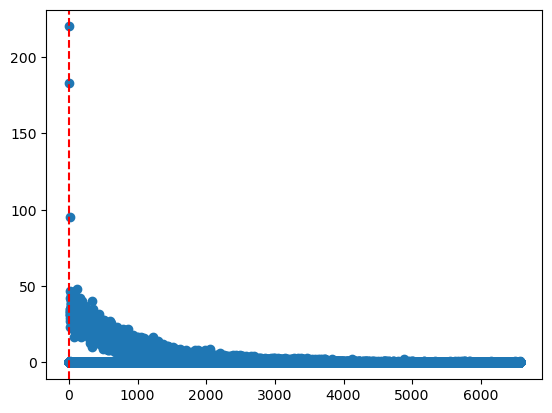

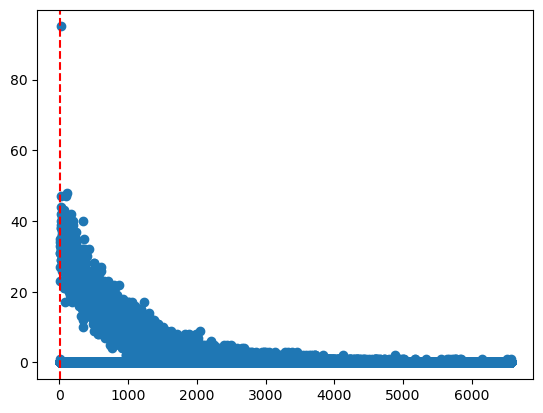

In [ ]:
# h,b = np.histogram(ts_us[1:]-ts_us[:-1], np.linspace(0, 1e3, 10000000))
times_us = np.asarray(ts_us, dtype=np.int64)
dt_us = np.diff(times_us)

h,b = np.histogram(dt_us, bins = 1000000)

plt.scatter(b[:-1], h)
plt.axvline(4.8, color='r', linestyle='--')

# plt.yscale('log')
# plt.xlim(4, 1e3)
# plt.xlim(0,1)
# plt.ylim( 400,410)

plt.show()

dt_us = np.diff(np.asarray(ts_us, dtype=np.int64))
dt_us_above_4_8 = dt_us[dt_us > 4.8]

h,b = np.histogram(dt_us_above_4_8, bins = 1000000)

plt.scatter(b[:-1], h)
plt.axvline(4.8, color='r', linestyle='--')
plt.show()

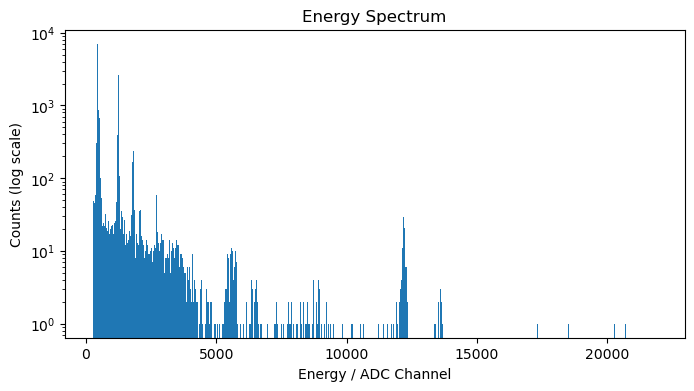

In [297]:


# # 1. Correct Plot for Raw Event Sequence
# plt.figure(figsize=(8, 4))
# plt.plot(energy, linewidth=0.5)
# plt.title("Pulse Height per Event")
# plt.xlabel("Event Index")
# plt.ylabel("Energy / ADC Channel")
# plt.show()

# 2. Correct Plot for True Energy Spectrum
plt.figure(figsize=(8, 4))
plt.hist(energy, bins=1024, log=True)
plt.title("Energy Spectrum")
plt.xlabel("Energy / ADC Channel")
plt.ylabel("Counts (log scale)")
plt.show()

In [ ]:

times = np.asarray(ts_us[1], dtype=np.float64)   # seconds
adu = np.asarray(energy, dtype=np.int32)

dt = np.diff(times)
dadu = np.diff(adu)
abs_dadu = np.abs(dadu)

# Select time-spacing groups
zero_mask = np.isclose(dt, 0.0, atol=1e-9)

target_dt = 1       # seconds
tolerance = 0.1     # accept 9.5–10.5 ms
target_mask = np.abs(dt - target_dt) <= tolerance


def summarize(label, mask):
    values = abs_dadu[mask]

    if values.size == 0:
        print(f"{label}: no matching pairs")
        return

    mean_abs = np.mean(values)
    max_abs = np.max(values)

    print(f"{label}")
    print(f"  Number of pairs:       {values.size}")
    print(f"  Mean absolute ΔADU:    {mean_abs:.3f}")
    print(f"  Max absolute ΔADU:  {max_abs:.3f}")

summarize("Δt = 0", zero_mask)
summarize("Δt ≈ 1 seconds", target_mask)

Δt = 0
  Number of pairs:       183
  Mean absolute ΔADU:    836.563
  Max absolute ΔADU:  11843.000
Δt ≈ 1 seconds
  Number of pairs:       220
  Mean absolute ΔADU:    0.000
  Max absolute ΔADU:  0.000


In [300]:
print (runfile)

run3


In [277]:
# def adu_to_kev(adu, gain, offset):
#     global C1, C2, C3, C4
#     return (1 / (C1 * gain)) * (adu - C2 * gain - C3 * offset) + C4

# def kev_to_adu(kev, gain, offset):
#     global C1, C2, C3, C4

#     return ((kev - C4) * (C1 * gain) + C2 * gain + C3 * offset)

In [278]:


# def adu_to_kev(adu, gain, offset):
#     return (1 / (C1 * gain)) * (adu - C2 * gain - C3 * offset) + C4

# def kev_to_adu( kev, gain, offset):
#     return (kev - C4) * (C1 * gain) + C2 * gain + C3 * offset

In [279]:
# MAX_Q15 = 32767 / 32768

# dev.set_register("peak_detector", "trig_level", 0.08)
# dev.set_register("peak_detector", "n_integration", 300)

# log = EventLogger(dev)
# log.configure(
#     band_low=0.0,
#     band_high=MAX_Q15,
#     flush_ms=100,
# )

# print("trigger:", dev.get_register("peak_detector", "trig_level", raw=True))
# print("integration:", dev.get_register("peak_detector", "n_integration", raw=True))
# print("logger band:", [
#     dev.get_register("event_logger", "band_low", raw=True),
#     dev.get_register("event_logger", "band_high", raw=True),
# ])

In [280]:
# log.arm(clear=True)

# for _ in range(10):
#     print(
#         "events =", dev.get_register("event_logger", "events_lo", raw=True),
#         "ready =", dev.get_register("event_logger", "ready", raw=True),
#         "count =", dev.get_register("event_logger", "ready_count", raw=True),
#         "peak =", dev.get_register("peak_detector", "peak_max_out", raw=True),
#     )
#     time.sleep(0.2)

# log.disarm()

In [281]:
# n = log.run(duration=5, output_dir="run2")
# print("drained events:", n)
# print("dropped:", log.dropped())

In [282]:
# log.arm(clear=True)

# # Signal chain
# dev.set_all_registers('iir1', compute_coeff.highpass_1st(1e4, Ts=16e-9), reset=True)

# for idx in range(9):
#     dev.set_register("fir9", f"h{idx}", 0.109375)


# # Peak detector
# dev.set_register("peak_detector", "trig_level", 0.008, raw=True)
# # dev.set_register("peak_detector", "fall_level", 1, raw=True)
# # dev.set_register("peak_detector", "base_return", 0, raw=True)
# # dev.set_register("peak_detector", "dead_time", 1000, raw=True)

# # Use 0 for positive-going pulses, 1 for negative-going pulses
# dev.set_register("peak_detector", "invert_input", 0, raw=True)


# dev.set_register("peak_detector", "n_integration", 300)

# # Histogram
# dev.set_register("histogram", "offset", -0.007165694774164504)
# dev.set_register("histogram", "gain", 0.08361136196556104)

# dev.set_register("histogram", "pulse_width", 1024)
# dev.set_register("histogram", "clear_bins", 1)
# time.sleep(0.01)
# dev.set_register("histogram", "clear_bins", 0)
# dev.set_register("histogram", "counting_enable", 1)
# # dev.set_register("histogram", "band_low", 0.0)
# # dev.set_register("histogram", "band_high", MAX_Q15)

# log = EventLogger(dev)
# log.configure(flush_ms=100)
# # log. /configure(flush_ms=100)

# log.run(duration=5, output_dir=f"{runfile}")

# log.disarm()

In [283]:

# RP_HOST = os.environ.get("RP_HOST", "171.64.56.120")
# dev = redpitaya_dev(RP_HOST, "config/mca_timestamp_1ch_working.json")
# dev.base.load_bitfile()

# # Signal chain
# dev.set_all_registers('iir1', compute_coeff.highpass_1st(1e4, Ts=16e-9), reset=True)
# dev.set_register('fir9', 'h0', 0.99)

# # Peak detector
# dev.set_register("peak_detector", "invert_input", 0)
# dev.set_register("peak_detector", "trig_level", 0.01)
# dev.set_register("peak_detector", "integration_mode", 0)
# dev.set_register("peak_detector", "n_integration", 1000)

# # Histogram
# dev.set_register("histogram", "offset", 0)
# dev.set_register("histogram", "gain", 0.1)
# dev.set_register("histogram", "band_low", 0.03)
# dev.set_register("histogram", "band_high", 0.35)
# dev.set_register("histogram", "pulse_width", 1024)
# dev.set_register("histogram", "clear_bins", 1)
# time.sleep(0.01)
# dev.set_register("histogram", "clear_bins", 0)

# log = EventLogger(dev)
# log.configure(flush_ms=100)
# log.run(duration=6, output_dir="run1")

In [284]:
# histogram = dev.read_sequential_axi_data("histogram", "read_address", "read_data", 0, 1023)
# plt.plot(histogram)

In [285]:
# dev.get_all_registers("histogram")
# # offset